# Project: SureVisit
SureVisit is a machine learning-based healthcare scheduling system designed to identify appointments at risk of being missed, helping healthcare providers improve scheduling reliability and optimize resource utilization.

# 1. Imports

In [1]:
# Core Libraries
import pandas as pd 
import numpy as np  

# Visualization
import matplotlib.pyplot as plt 
import seaborn as sns

# 2. Load Data

In [2]:
df = pd.read_csv("../data/raw/KaggleV2-May-2016.csv")
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


# 3. Data Overview

In [3]:
df.shape

(110527, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [5]:
# Number of Columns
len(df.columns)

14

# 4. Missing Values Check

In [6]:
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

# 5. Check Duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

# 6. Age Sanity Check

In [8]:
df['Age'].describe()

count    110527.000000
mean         37.088874
std          23.110205
min          -1.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64

# 7. Target Variable Distribution

In [9]:
df['No-show'].value_counts()

No-show
No     88208
Yes    22319
Name: count, dtype: int64

In [10]:
df['No-show'].value_counts(normalize=True)

No-show
No     0.798067
Yes    0.201933
Name: proportion, dtype: float64

# 8. Categorical Columns — Unique Values

In [11]:
df['Gender'].unique()

array(['F', 'M'], dtype=object)

In [12]:
df['Handcap'].unique()

array([0, 1, 2, 3, 4])

In [13]:
df['Neighbourhood'].nunique()

81

# 9. Target Distribution Visualization

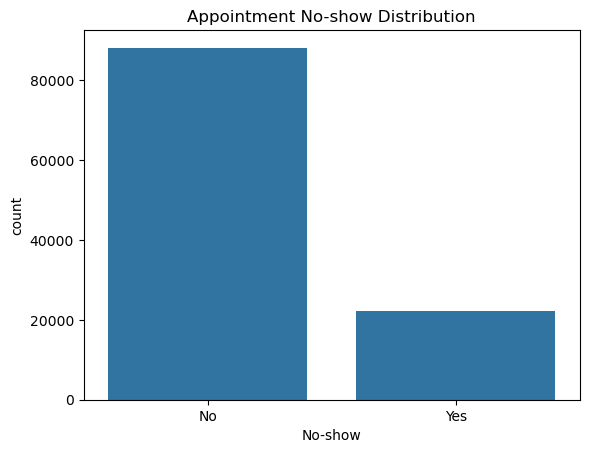

In [14]:
sns.countplot(data=df, x='No-show')
plt.title('Appointment No-show Distribution')
plt.show()
plt.close()

# 10. Age vs No-show Analysis

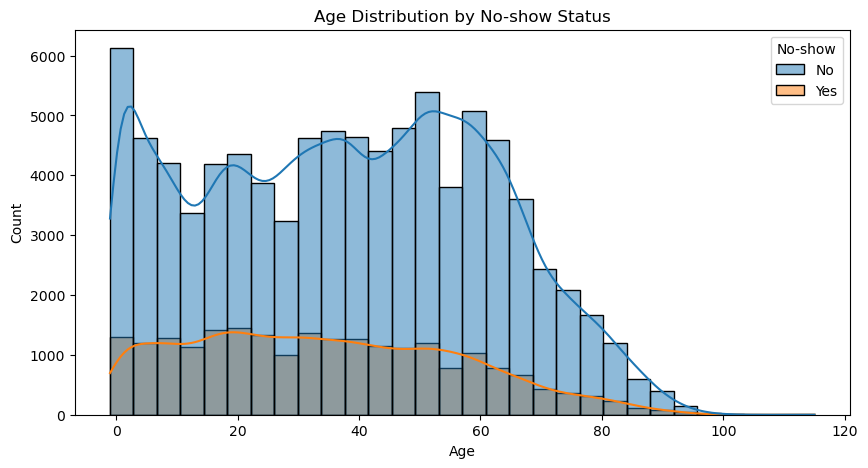

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Age', hue='No-show', bins=30, kde=True)
plt.title('Age Distribution by No-show Status')
plt.show()
plt.close()

# 11. SMS Received vs No-show Analysis

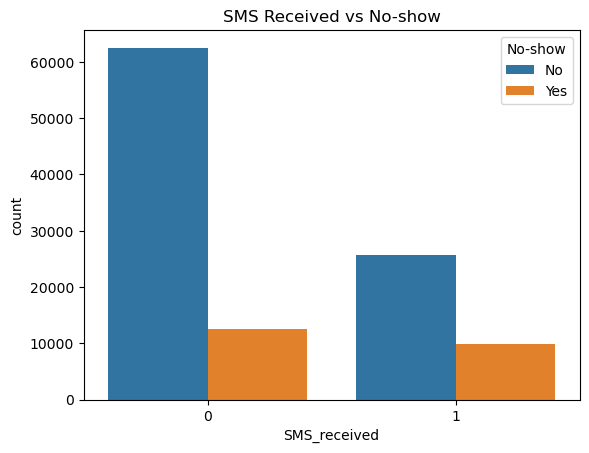

In [16]:
sns.countplot(data=df, x='SMS_received', hue='No-show')
plt.title('SMS Received vs No-show')
plt.show()
plt.close()

# 12. Waiting Period Analysis

In [17]:
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
df['WaitingDays'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days
df['WaitingDays'].describe()

count    110527.000000
mean          9.183702
std          15.254996
min          -7.000000
25%          -1.000000
50%           3.000000
75%          14.000000
max         178.000000
Name: WaitingDays, dtype: float64

# 13. Waiting Days vs No-show Visualization

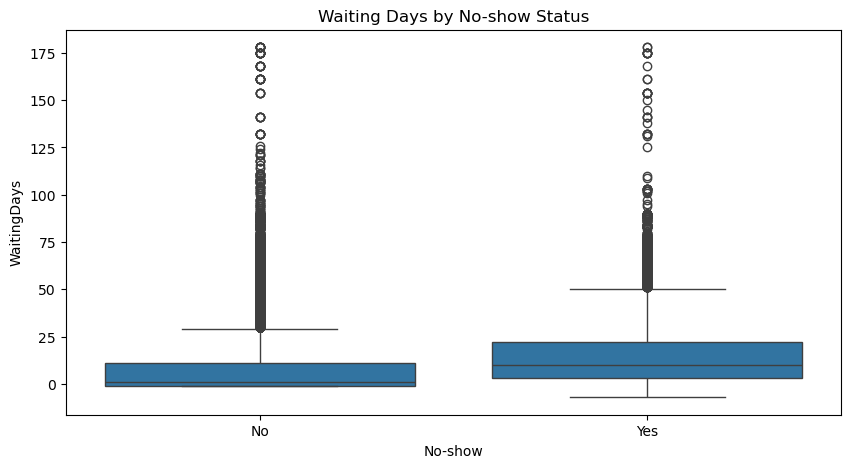

In [18]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='No-show', y='WaitingDays')
plt.title('Waiting Days by No-show Status')
plt.show()
plt.close()

# 14. Gender vs No-show Analysis

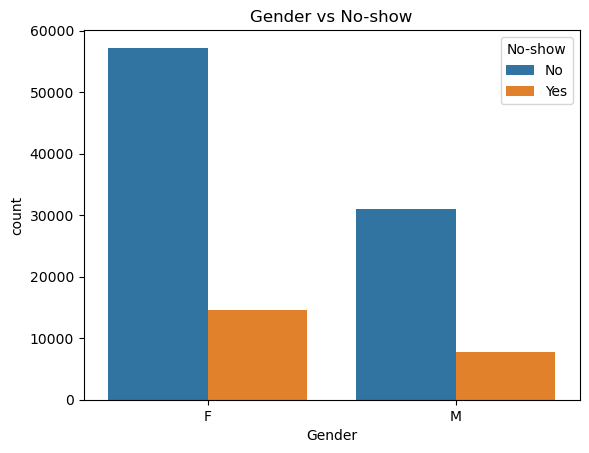

In [19]:
sns.countplot(data=df, x='Gender', hue='No-show')
plt.title('Gender vs No-show')
plt.show()
plt.close()

# 15. Correlation Heatmap (Numerical Features)

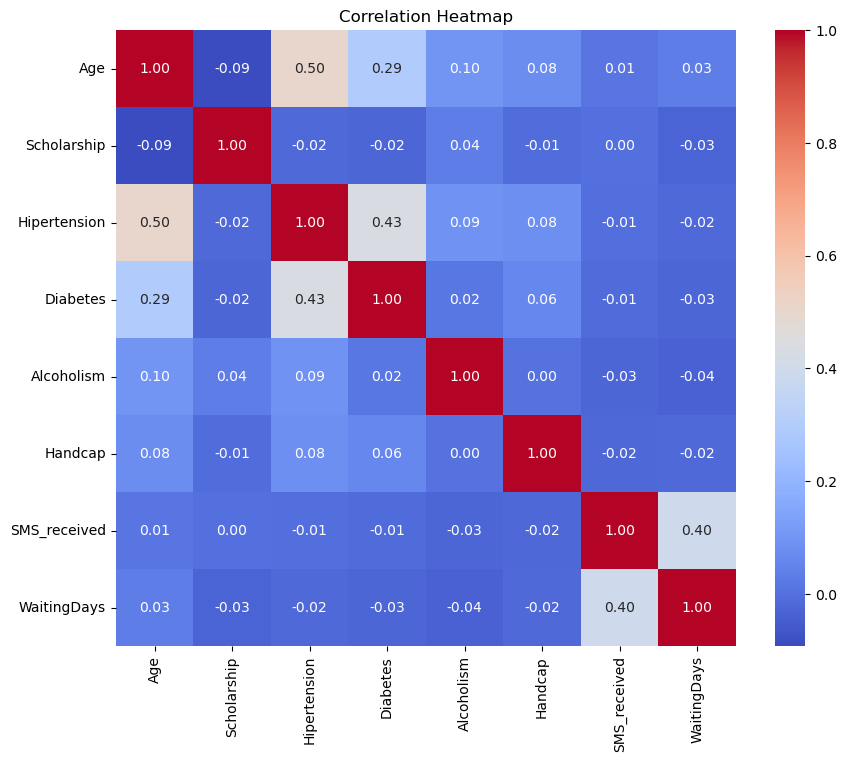

In [20]:
numeric_cols = ['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'WaitingDays']
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()
plt.close()

# 16. EDA Summary & Key Findings

- Dataset has 110,527 records, no missing values, but contains data quality issues.
- Target variable is imbalanced: ~80% attended, ~20% no-show.
- Age column has invalid values (min = -1), needs cleaning.
- WaitingDays has negative values due to time-component mismatch between ScheduledDay and AppointmentDay — needs correction.
- Handcap is not binary; ranges from 0 to 4 (severity levels).
- Neighbourhood has high cardinality (81 unique values) — requires encoding strategy.
- These findings will be addressed in the preprocessing phase (02_preprocessing.ipynb).